# Bubble analysis

Reviewed bubbles exported by `bubble_inference.ipynb` (`results/<RUN_NAME>/`), one or more frames per train, from one
or several runs (e.g. r571 + r572, the same event at later times). To compare runs, predict and review them into the
same results folder (`RUN_NAME` in bubble_inference.ipynb).

**Physical picture:** each laser pulse ablates tissue and leaves cavitation/vapour bubbles. Between scan layers (trains,
minutes apart) the bubbles from earlier pulses **coalesce, drift, merge and dissolve**. That changes their number, size,
shape and position. The sections below track exactly these:

| section | question |
|---|---|
| 2 metrics table | all numbers per frame in one table (saved as `frame_metrics.csv`) |
| 3 count | how many bubbles, per frame and per mm² |
| 4 average size | mean, median and Sauter radius r₃₂ over time |
| 5 total area | how much of the field of view the bubbles cover (sum of areas, and area covered) |
| 6 size distributions | histograms per frame, cumulative distributions, scaled distribution r/⟨r⟩ (self-similar coarsening?) |
| 7 size classes + coalescence check | which sizes disappear; is gas volume conserved (coalescence) or lost (dissolution)? |
| 8 overlays | every frame with bubbles coloured by area (green = small → red = large, one shared scale) |
| 9 spatial | where bubbles are, and how the population drifts |
| 10 shape | elongated bubbles (recent mergers) vs size and time |

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import bubble_io as bio
import bubble_stats as bst

bst.style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## CONFIG

In [50]:
RUN_DIR = "results/r574"
REVIEWED_ONLY = False          # only frames ticked "Reviewed" in napari
IN_ANALYSIS_ONLY = True       # apply the exclusions chosen at export (inner_margin, drop_edge_bubbles, ...)
TRAIN_TIMES = None            # optional {train: time} or {(run, train): time}, e.g. {("r571", 0): 0, ("r572", 0): 30};
                              # None = train number (several runs: numbered on from one run to the next)
TIME_LABEL = "train"          # axis label, e.g. "time [min]"
UM_PER_PX = 3.2

HIST_VAR, HIST_LABEL = "r_eq_um", "equivalent radius [µm]"   # or "area_um2", "area [µm²]"
SIZE_CLASSES_UM = [0, 10, 20, 40, np.inf]                     # radius classes for section 6 (max 4 classes)
OVERLAY_CMAP = "RdYlGn_r"     # green (small) -> yellow -> red (large); "viridis" is colour-blind safe
OVERLAY_ALPHA = 0.45          # fill opacity of the overlays
DENSITY_CELL_UM = 80          # cell size of the spatial density maps

SAVE_FIGS = True              # save every figure as PNG into RUN_DIR/figures/
FIG_DIR = os.path.join(RUN_DIR, "figures")

def save(fig, name):
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=200, bbox_inches="tight")

## 1. Load

In [51]:
bubbles, frames = bio.load_results(RUN_DIR, reviewed_only=REVIEWED_ONLY, in_analysis_only=IN_ANALYSIS_ONLY)
frames["t"] = bst.train_times(frames, TRAIN_TIMES)
bubbles["t"] = bubbles["frame"].map(frames.set_index("frame")["t"])
frames = frames.sort_values(["t", "frame"]).reset_index(drop=True)
NATIVE_HW = (int(frames["image_height_px"].iloc[0]), int(frames["image_width_px"].iloc[0]))
print(f"{len(frames)} frames, runs {sorted(frames['run'].unique().tolist())}, trains {sorted(frames['train'].unique().tolist())}, "
      f"{len(bubbles)} bubbles, field of view {NATIVE_HW[1] * UM_PER_PX:.0f} × {NATIVE_HW[0] * UM_PER_PX:.0f} µm")
display(frames[["frame", "run", "train", "frame_idx", "t", "n_bubbles", "n_in_analysis"]])

7 frames, runs ['r574'], trains [0, 1, 2, 3, 4, 5, 6], 1881 bubbles, field of view 1280 × 800 µm


,frame,run,train,frame_idx,t,n_bubbles,n_in_analysis
0,r574_svd_normalised_tr050_tid0_010,r574,0,10,0.0,15,15
1,r574_svd_normalised_tr050_tid1_010,r574,1,10,1.0,19,19
2,r574_svd_normalised_tr050_tid2_010,r574,2,10,2.0,24,24
3,r574_svd_normalised_tr050_tid3_010,r574,3,10,3.0,25,25
4,r574_svd_normalised_tr050_tid4_010,r574,4,10,4.0,584,584
5,r574_svd_normalised_tr050_tid5_010,r574,5,10,5.0,624,624
6,r574_svd_normalised_tr050_tid6_010,r574,6,10,6.0,590,590


**Columns in `bubbles`** (lengths in native px, `_um` / `_um2` in µm): `run, train, frame_idx` · `x, y` centre (edge bubbles: fitted centre,
may lie outside the image) · `area_px2`, `r_eq` full-bubble area and equivalent radius √(area/π) · `major_axis`,
`minor_axis`, `orientation_deg`, `eccentricity` · `area_visible_px2` part inside the image · `edge_truncated`,
`shape_type` (circle / ellipse) · `arc_deg`, `fit_reliable` edge handling · `in_analysis` export exclusions.

## 2. Metrics per frame

`r32_um` is the Sauter mean radius Σr³/Σr² (dominated by the large bubbles, standard in foam/bubble science),
`polydispersity` = std/mean of r, `coverage_frac` = fraction of the frame covered by at least one bubble (overlaps
counted once), `volume_um3` = Σ 4/3πr³ (sphere-equivalent gas volume proxy), `cx_um, cy_um` = area-weighted centroid.

In [52]:
m = bst.frame_metrics(bubbles, frames, run_dir=RUN_DIR, um_per_px=UM_PER_PX)
m.to_csv(os.path.join(RUN_DIR, "frame_metrics.csv"), index=False)
cols = ["run", "train", "t", "n_bubbles", "density_per_mm2", "r_mean_um", "r_sem_um", "r_median_um", "r32_um", "r_max_um",
        "polydispersity", "coverage_frac", "area_total_um2", "volume_um3", "frac_noncircular", "n_edge"]
display(m[cols].round(3))

,run,train,t,n_bubbles,density_per_mm2,r_mean_um,r_sem_um,r_median_um,r32_um,r_max_um,polydispersity,coverage_frac,area_total_um2,volume_um3,frac_noncircular,n_edge
0,r574,0,0.0,15,14.648,18.865,2.554,16.904,28.334,36.547,0.524,0.021,21074.531,7.961752e+05,0.000,1
1,r574,1,1.0,19,18.555,17.468,2.052,13.710,26.664,36.323,0.512,0.021,22740.146,8.084541e+05,0.158,1
2,r574,2,2.0,24,23.438,17.314,1.923,15.981,26.794,35.992,0.544,0.028,29014.959,1.036550e+06,0.042,1
3,r574,3,3.0,25,24.414,18.142,2.964,12.830,47.776,76.842,0.817,0.041,42409.935,2.701577e+06,0.080,1
4,r574,4,4.0,584,570.312,14.036,0.408,10.538,30.734,80.129,0.702,0.383,539101.006,2.209172e+07,0.039,41
5,r574,5,5.0,624,609.375,14.175,0.386,11.066,29.818,79.010,0.680,0.396,575939.899,2.289781e+07,0.035,39
6,r574,6,6.0,590,576.172,14.783,0.469,10.962,40.803,134.413,0.770,0.390,644929.525,3.508715e+07,0.037,42


## 3. Bubble count

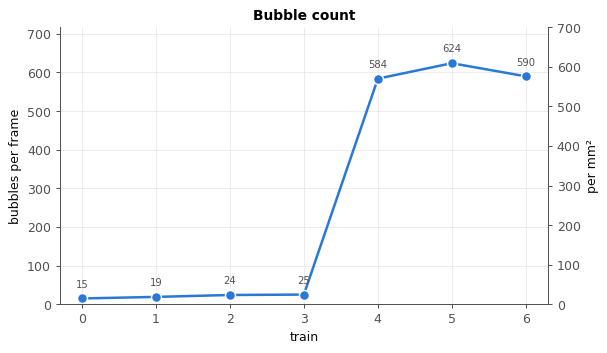

In [53]:
fig, ax = plt.subplots(figsize=(7, 4))
bst.plot_count(m, TIME_LABEL, ax=ax)
save(fig, "count")

## 4. Average bubble size

Mean and median describe the *typical* bubble. The Sauter radius r₃₂ follows the *large* bubbles, which hold most of
the gas. Growth of all three with fewer bubbles is the signature of coalescence. A sudden drop marks a fresh
population of small bubbles (e.g. a new scan layer).

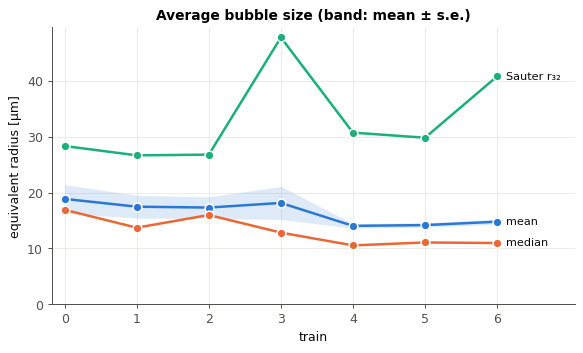

In [54]:
fig, ax = plt.subplots(figsize=(7.5, 4))
bst.plot_mean_size(m, TIME_LABEL, ax=ax)
save(fig, "mean_size")

## 5. Total bubble area

How much of the field of view the bubbles take up. **Total** adds up every bubble's area, so overlapping bubbles count
fully (it can exceed the field of view). **Covered** is the area under at least one bubble, overlaps counted once.
Total rising while the count falls: coalescence into bigger bubbles; total falling: dissolution or bubbles leaving the view.

,run,train,t,area_total_um2,coverage_frac
0,r574,0,0.0,21074.5311,0.0205
1,r574,1,1.0,22740.1455,0.0209
2,r574,2,2.0,29014.9594,0.0283
3,r574,3,3.0,42409.9348,0.0409
4,r574,4,4.0,539101.0057,0.3832
5,r574,5,5.0,575939.8991,0.3962
6,r574,6,6.0,644929.5250,0.3900


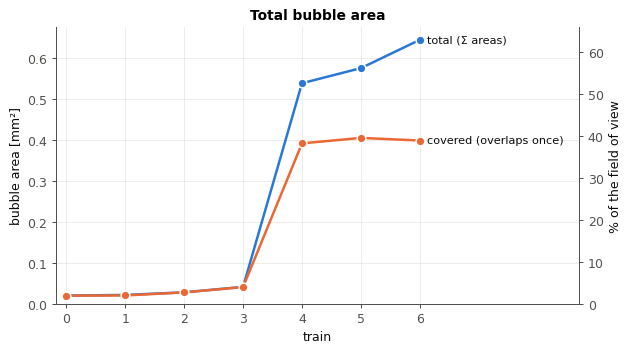

In [55]:
fig, ax = plt.subplots(figsize=(7.5, 4))
bst.plot_total_area(m, TIME_LABEL, ax=ax)
save(fig, "total_area")
display(m[["run", "train", "t", "area_total_um2", "coverage_frac"]].round(4))

## 6. Size distributions

* **Histograms** (log bins): one panel per frame, the first frame as dashed outline for comparison.
* **Cumulative distributions**: a curve shifting right = bubbles growing.
* **Scaled distribution** r/⟨r⟩: if the curves collapse onto one shape, the foam coarsens self-similarly (only the
  scale changes). A curve that does not collapse points to a different process, such as a new bubble population.

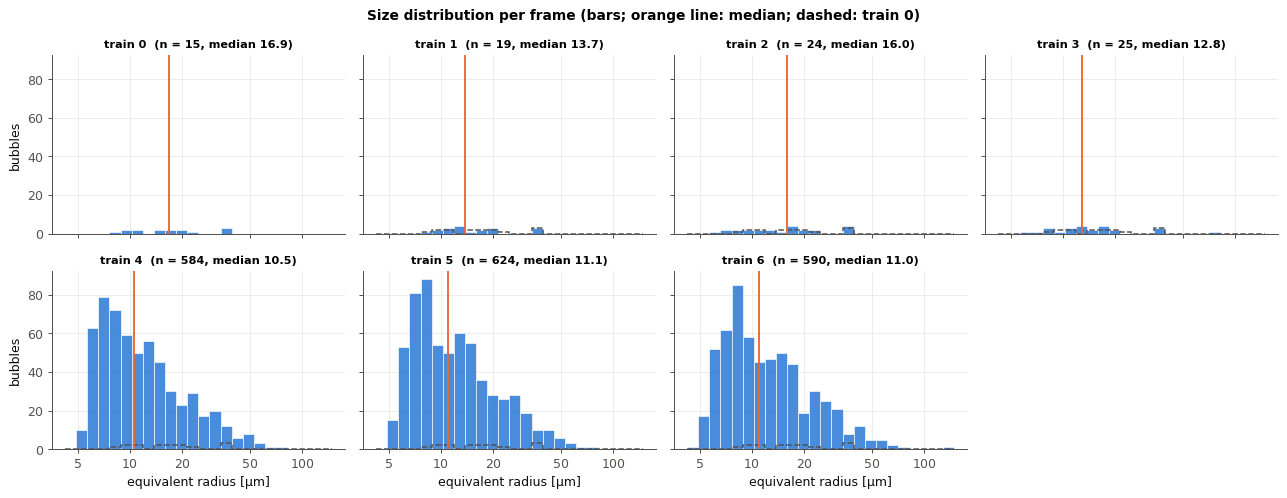

In [56]:
fig = bst.plot_histograms(bubbles, m, var=HIST_VAR, xlabel=HIST_LABEL)
save(fig, "histograms")

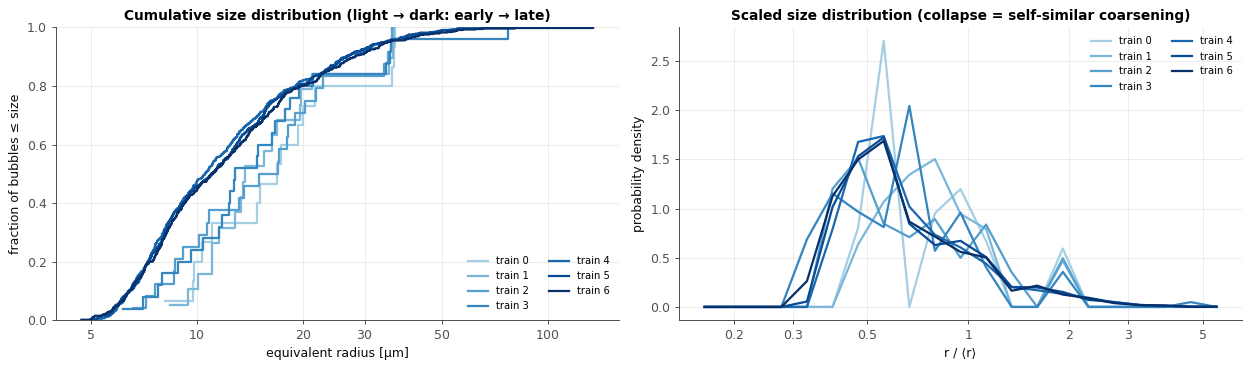

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
bst.plot_cdfs(bubbles, m, var=HIST_VAR, xlabel=HIST_LABEL, ax=ax[0])
bst.plot_scaled_distribution(bubbles, m, ax=ax[1])
fig.tight_layout()
save(fig, "distributions")

## 7. Size classes and coalescence check

* **Size classes:** whether small bubbles vanish while large ones gain.
* **Relative change** (all quantities divided by their value in the first frame):
  * pure **coalescence** keeps the gas volume roughly constant while the count falls and the radius grows;
  * **dissolution** loses volume;
  * **new bubbles** raise the count and lower the radius.

  The volume proxy assumes spherical bubbles seen in projection, so read trends, not absolute values.

size_class,t,frame,0–10 µm,10–20 µm,20–40 µm,≥ 40 µm
0,0.0,r574_svd_normalised_tr050_tid0_010,3,7,5,0
1,1.0,r574_svd_normalised_tr050_tid1_010,2,13,4,0
2,2.0,r574_svd_normalised_tr050_tid2_010,6,11,7,0
3,3.0,r574_svd_normalised_tr050_tid3_010,6,14,4,1
4,4.0,r574_svd_normalised_tr050_tid4_010,278,201,89,16
5,5.0,r574_svd_normalised_tr050_tid5_010,286,218,104,16
6,6.0,r574_svd_normalised_tr050_tid6_010,264,208,96,22


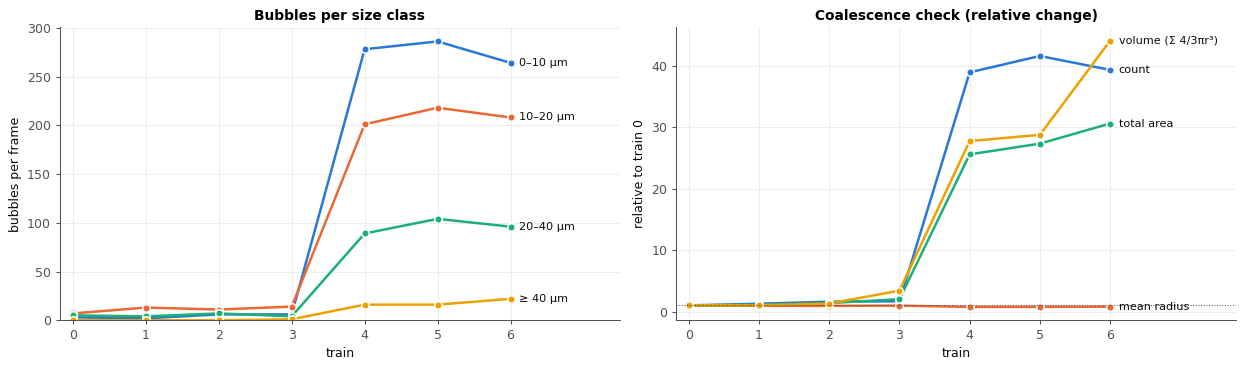

In [58]:
counts, labels = bst.size_class_counts(bubbles, SIZE_CLASSES_UM)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
bst.plot_size_classes(counts, labels, TIME_LABEL, ax=ax[0])
bst.plot_relative(m, TIME_LABEL, ax=ax[1])
fig.tight_layout()
save(fig, "size_classes_relative")
display(counts)

## 8. Overlays coloured by bubble area

Green = small, red = large, on one **shared logarithmic** colour scale, so the same colour means the same area in
every frame. Large bubbles are drawn first so small ones on top stay visible.

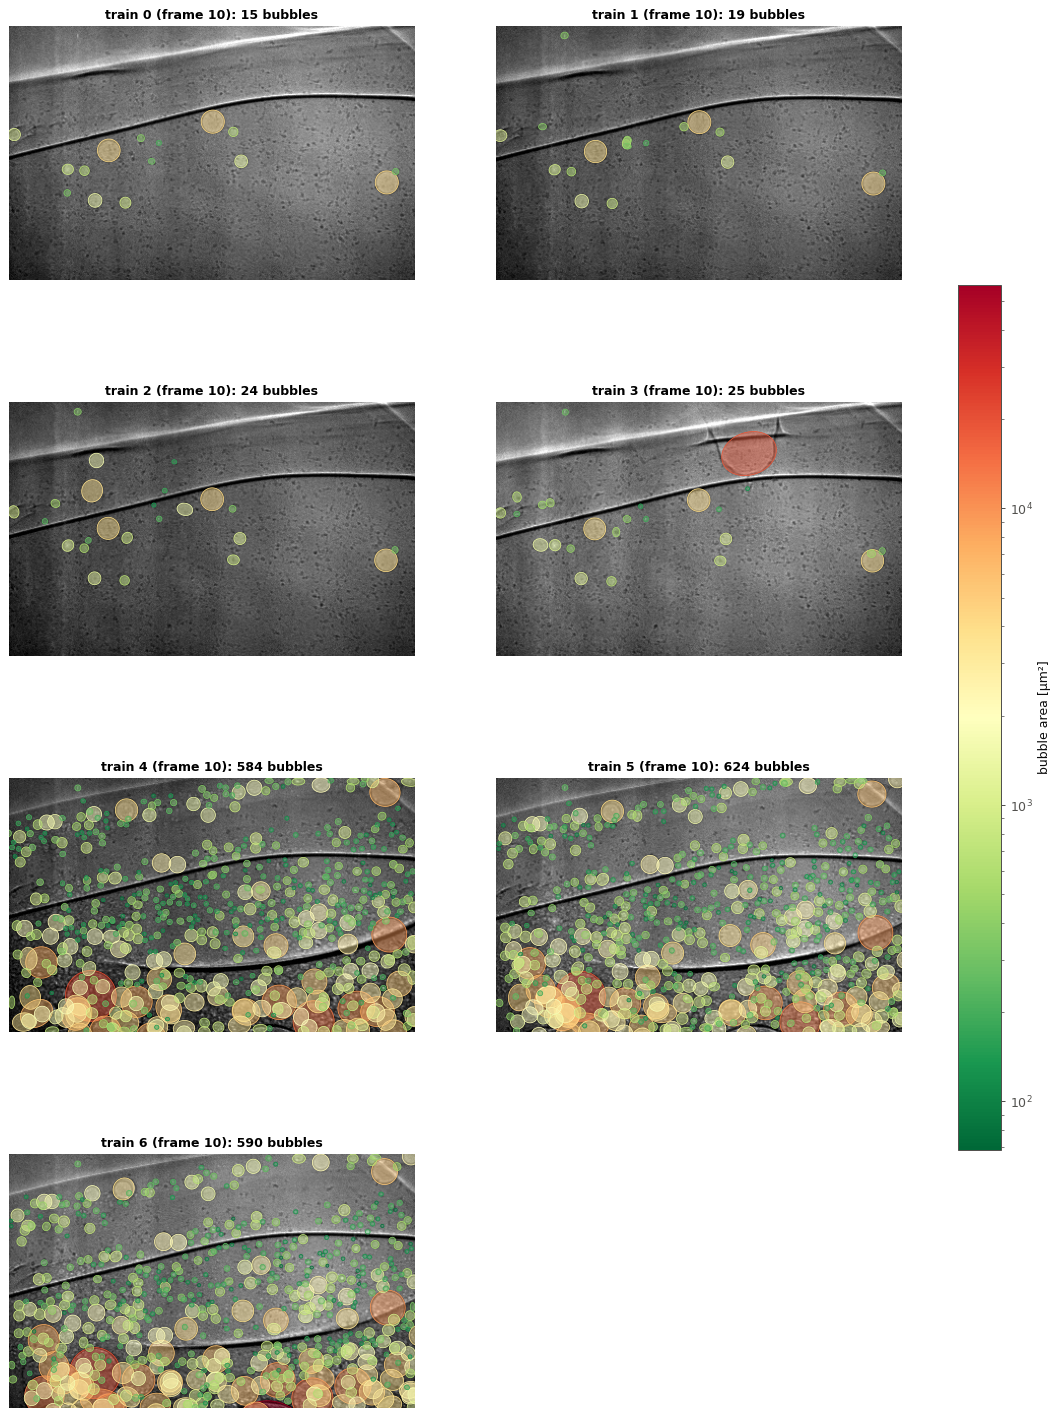

In [59]:
norm = bst.area_norm(bubbles, "area_um2")
ncols = 2
nrows = int(np.ceil(len(m) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5.2 * nrows), squeeze=False)
for ax, (_, r) in zip(axs.ravel(), m.iterrows()):
    img, shapes = bio.load_frame(RUN_DIR, r["frame"])
    b = bubbles[bubbles["frame"] == r["frame"]]
    bst.plot_area_overlay(img, [shapes[i] for i in b["bubble_id"]], b["area_um2"].to_numpy(), norm,
                          cmap=OVERLAY_CMAP, ax=ax, alpha=OVERLAY_ALPHA,
                          title=f"{bst.train_label(r)} (frame {r['frame_idx']}): {len(b)} bubbles")
for ax in axs.ravel()[len(m):]:
    ax.set_visible(False)
sm = plt.cm.ScalarMappable(norm=norm, cmap=OVERLAY_CMAP)
fig.colorbar(sm, ax=axs.ravel().tolist(), shrink=0.6, label="bubble area [µm²]")
save(fig, "overlays_area")

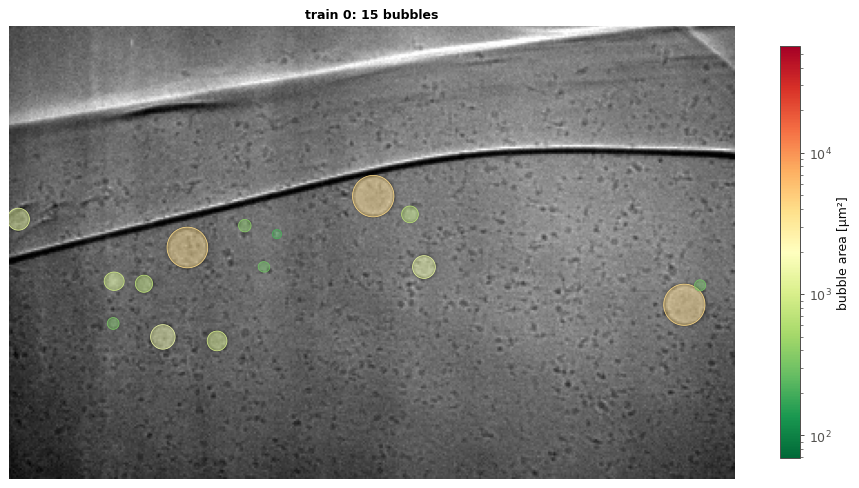

In [60]:
# one frame, large
SHOW_FRAME = m["frame"].iloc[0]          # or any frame name from the table in section 1
r = m[m["frame"] == SHOW_FRAME].iloc[0]
img, shapes = bio.load_frame(RUN_DIR, r["frame"])
b = bubbles[bubbles["frame"] == r["frame"]]
fig, ax = plt.subplots(figsize=(13, 8.5))
bst.plot_area_overlay(img, [shapes[i] for i in b["bubble_id"]], b["area_um2"].to_numpy(), norm,
                      cmap=OVERLAY_CMAP, ax=ax, alpha=OVERLAY_ALPHA, title=f"{bst.train_label(r)}: {len(b)} bubbles")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=OVERLAY_CMAP), ax=ax, shrink=0.7, label="bubble area [µm²]")
save(fig, f"overlay_area_train{r['train']}" if frames["run"].nunique() == 1 else f"overlay_area_{r['run']}_train{r['train']}")

## 9. Spatial distribution and drift

Density maps show where the bubbles sit (shared colour scale). The centroid path follows the area-weighted centre of
the whole population from train to train: a consistent direction means collective drift (e.g. buoyancy or flow).
Individual bubbles are not tracked, because they merge and move too much between trains.

,run,train,t,cx_um,cy_um,step_um
0,r574,0,0.0,580.0,414.9,NaN
1,r574,1,1.0,562.7,401.2,22.1
2,r574,2,2.0,507.8,376.1,60.3
3,r574,3,3.0,651.3,301.1,162.0
4,r574,4,4.0,652.7,565.2,264.1
5,r574,5,5.0,629.6,572.2,24.2
6,r574,6,6.0,659.2,617.5,54.1


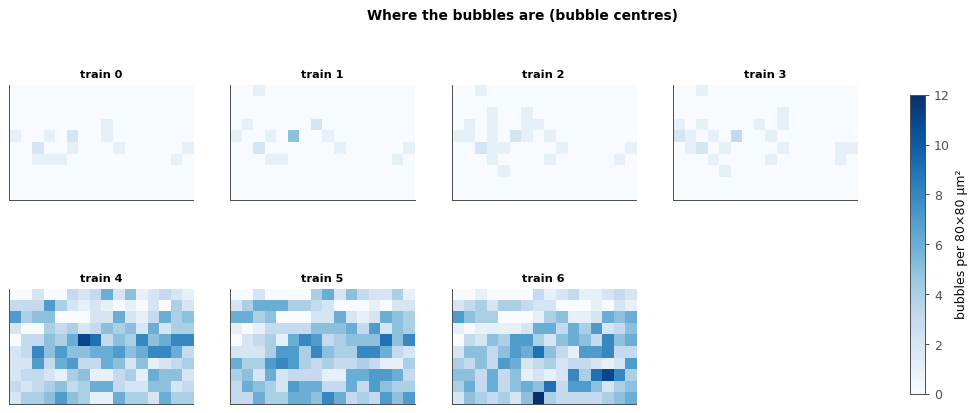

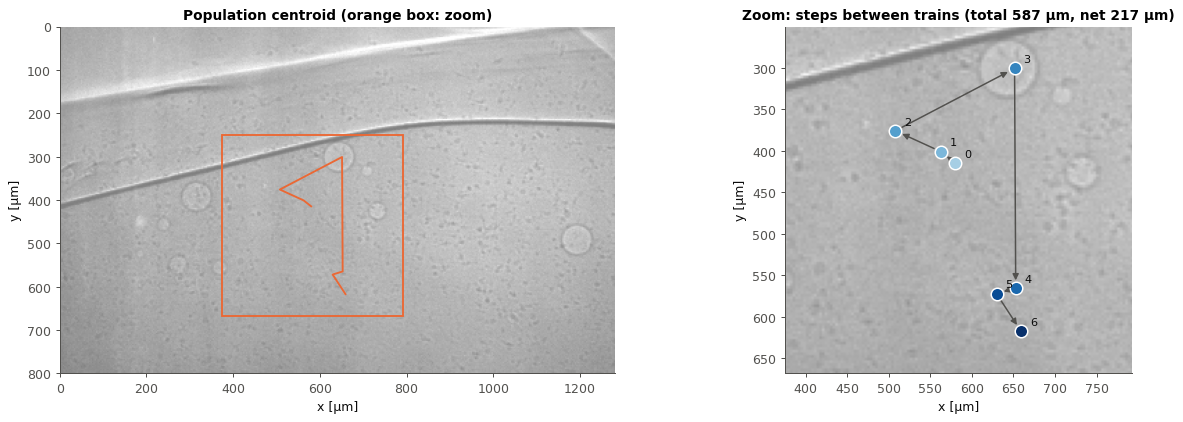

In [61]:
fig = bst.plot_density_maps(bubbles, m, NATIVE_HW, um_per_px=UM_PER_PX, cell_um=DENSITY_CELL_UM)
save(fig, "density_maps")

img0, _ = bio.load_frame(RUN_DIR, m["frame"].iloc[0])
fig = bst.plot_drift(m, NATIVE_HW, um_per_px=UM_PER_PX, img=img0, time_label=TIME_LABEL)
save(fig, "drift")
display(m[["run", "train", "t", "cx_um", "cy_um"]].assign(
    step_um=np.r_[np.nan, np.hypot(np.diff(m["cx_um"]), np.diff(m["cy_um"]))]).round(1))

## 10. Shape

Freshly merged bubbles are elongated before surface tension rounds them. The share of non-circular bubbles is a rough
indicator of recent merging activity.

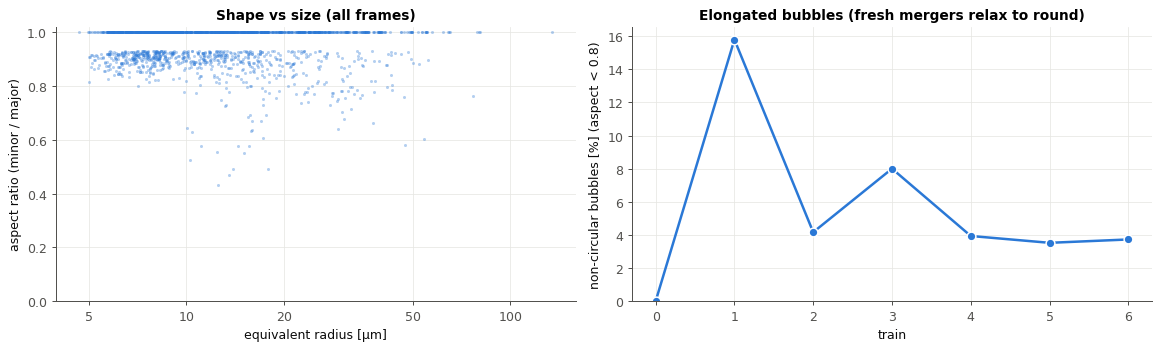

In [62]:
fig = bst.plot_shape(bubbles, m, TIME_LABEL)
save(fig, "shape")

## Caveats

* Images are 2-D projections of a 3-D foam: overlapping bubbles are all counted, `area_total_um2` can exceed the frame
  area, and `coverage_frac` counts overlaps once.
* Bubbles cut by the image edge use their fitted full size (`fit_reliable=False` for short visible arcs). Use the
  export options (`inner_margin`, `drop_unreliable_fits`) if edge effects matter for a comparison.
* With one frame per train, frame-to-frame scatter within a train is unknown. With several frames per train
  (e.g. `("r571", "all", "10-14")` in bubble_inference.ipynb), each frame is its own point at the train's time, so
  their spread shows that scatter.

## Your analysis